In [1]:
#! pip install pandas numpy
import pandas as pd
import numpy as np

In [3]:
import os
print(os.getcwd())

/Users/sbeddyy/Desktop/FORMATION/data_S_IDMC/CM-Python-AV/projet-py/notebooks


In [2]:
# Charger les données
log = pd.read_csv("DATA/df/log.csv")
notes = pd.read_csv("DATA/df/notes.csv")

In [4]:
def format_pourcentage(value):
    return "{0:.1f}%".format(value * 100)
df = pd.DataFrame(columns = ["N_Lignes", "N_colonnes", "Pourcentage de NAN", "Doublons"], 
                  index = [ "log.csv", "notes.csv"])

df["N_Lignes"] = [
    len(log.index),
    len(notes.index),    
]
df["N_colonnes"] = [
    len(log.columns),
    len(notes.columns),
]
df["Pourcentage de NAN"] = [
    format_pourcentage(log.isna().mean().mean()),
    format_pourcentage(notes.isna().mean().mean())
]

df["Doublons"] = [
    log.duplicated().sum(),
    notes.duplicated().sum(),
]

df

,N_Lignes,N_colonnes,Pourcentage de NAN,Doublons
log.csv,16227,5,0.0%,28
notes.csv,99,2,0.0%,0


## Analyse des doublons
**Contexte**
Avant de nettoyer les données, on a analysé les deux types de doublons dans les logs ARCHE.

***Type 1 : Doublons exacts***
- Définition : Lignes 100% identiques (même seconde, même tout)
- Résultat : 28 lignes
- Cause : Bug technique (double enregistrement) 
- Action : Supprimer avec ***drop_duplicates()***

**Type 2 : Répétitions identiques < 5 secondes**
- Définition : Même étudiant, même action, moins de 5 secondes d'écart
- Résultat : 246 lignes
- Cause : Double-clics, bugs de navigation
- Action : Supprimer avec ***log_clean = log_clean[~mask_bug]***

In [5]:
log['heure'] = pd.to_datetime(log['heure'])

# Trier par pseudo et heure
log_sorted = log.sort_values(['pseudo', 'heure'])

# Calculer la différence de temps entre chaque action d'un même pseudo
log_sorted['diff_seconds'] = log_sorted.groupby('pseudo')['heure'].diff().dt.total_seconds()

# Combien d'actions sont très rapprochées (moins de 5 secondes) ?
print(log_sorted[log_sorted['diff_seconds'] < 5].shape[0])

7773


In [6]:
# Actions rapprochées (< 5 sec)
rapides = log_sorted[log_sorted['diff_seconds'] < 5]

# Combien sont des actions IDENTIQUES (même contexte + même evenement) ?
# On compare avec la ligne précédente
log_sorted['meme_contexte'] = log_sorted['contexte'] == log_sorted.groupby('pseudo')['contexte'].shift(1)
log_sorted['meme_evenement'] = log_sorted['evenement'] == log_sorted.groupby('pseudo')['evenement'].shift(1)

# Actions rapides ET identiques
rapides_identiques = log_sorted[(log_sorted['diff_seconds'] < 5) & 
                                 (log_sorted['meme_contexte'] == True) & 
                                 (log_sorted['meme_evenement'] == True)]

print(f"Actions rapprochées (< 5 sec) : {len(log_sorted[log_sorted['diff_seconds'] < 5])}")
print(f"Dont actions identiques répétées : {len(rapides_identiques)}")

Actions rapprochées (< 5 sec) : 7773
Dont actions identiques répétées : 246


In [7]:
# 1. Supprimer les doublons exacts
log_clean = log.drop_duplicates()

# 2. Vérifier
print(f"Avant : {len(log)} lignes")
print(f"Après : {len(log_clean)} lignes")
print(f"Supprimées : {len(log) - len(log_clean)} lignes")

Avant : 16227 lignes
Après : 16199 lignes
Supprimées : 28 lignes


In [8]:
# Trier par pseudo et heure
log_clean = log_clean.sort_values(['pseudo', 'heure'])

# Recalcule les colonnes d'analyse
log_clean['heure'] = pd.to_datetime(log_clean['heure'])
log_clean['diff_seconds'] = log_clean.groupby('pseudo')['heure'].diff().dt.total_seconds()
log_clean['meme_contexte'] = log_clean['contexte'] == log_clean.groupby('pseudo')['contexte'].shift(1)
log_clean['meme_evenement'] = log_clean['evenement'] == log_clean.groupby('pseudo')['evenement'].shift(1)

#  les répétitions identiques < 5 sec
mask_bug = (log_clean['diff_seconds'] < 5) & (log_clean['meme_contexte']) & (log_clean['meme_evenement'])

# Combien de True (lignes à supprimer) ?
print(f"Lignes à supprimer : {mask_bug.sum()}")

# Voir les lignes concernées
log_clean[mask_bug]

Lignes à supprimer : 224


,heure,pseudo,contexte,composant,evenement,diff_seconds,meme_contexte,meme_evenement
158,2024-09-11 15:51:26,15,Cours: PASS - S1 - UE Disciplinaire Informatiq...,Système,Cours consulté,3.0,True,True
1555,2024-09-18 11:25:48,15,Cours: PASS - S1 - UE Disciplinaire Informatiq...,Système,Cours consulté,2.0,True,True
5141,2024-10-18 14:38:15,15,"Test: Test : Ch. 1 – Variable, type et instruc...",Test,Tentative de test relue,2.0,True,True
5152,2024-10-18 14:44:18,15,Test: Test : Ch. 2 – Conditionnelle simple,Test,Tentative de test relue,1.0,True,True
5163,2024-10-18 14:50:00,15,Test: Test : Ch. 3 – Les itérations,Test,Tentative de test relue,3.0,True,True
...,...,...,...,...,...,...,...,...
10611,2024-11-14 17:39:00,899,Test: Quiz Leçon 4,Test,Tentative de test relue,2.0,True,True
881,2024-09-14 12:27:10,903,Fichier: Feuille TD2,Fichier,Module de cours consulté,3.0,True,True
882,2024-09-14 12:27:14,903,Fichier: Feuille TD2,Fichier,Module de cours consulté,4.0,True,True
884,2024-09-14 12:27:19,903,Fichier: Correction de la feuille de TD 2,Fichier,Module de cours consulté,3.0,True,True


In [9]:
# le pseudo 903 en détail
log_clean[log_clean['pseudo'] == 903].head(10)

,heure,pseudo,contexte,composant,evenement,diff_seconds,meme_contexte,meme_evenement
228,2024-09-11 17:47:01,903,Cours: PASS - S1 - UE Disciplinaire Informatiq...,Système,Cours consulté,NaN,False,False
600,2024-09-13 15:00:11,903,Cours: PASS - S1 - UE Disciplinaire Informatiq...,Système,Cours consulté,162790.0,True,True
601,2024-09-13 15:00:14,903,Cours: PASS - S1 - UE Disciplinaire Informatiq...,Système,Liste d’utilisateurs consultée,3.0,True,False
602,2024-09-13 15:02:04,903,Cours: PASS - S1 - UE Disciplinaire Informatiq...,Système,Cours consulté,110.0,True,False
603,2024-09-13 15:02:12,903,Fichier: ModeEmploiAlgo,Fichier,Module de cours consulté,8.0,False,False
604,2024-09-13 15:04:06,903,Fichier: Conseils,Fichier,Module de cours consulté,114.0,False,True
605,2024-09-13 15:04:39,903,Fichier: Conventions,Fichier,Module de cours consulté,33.0,False,True
606,2024-09-13 15:07:10,903,Fichier: Méthodologie,Fichier,Module de cours consulté,151.0,False,True
607,2024-09-13 15:09:41,903,Fichier: Contrat,Fichier,Module de cours consulté,151.0,False,True
608,2024-09-13 15:17:25,903,Autre,Fichier,Module de cours consulté,464.0,False,True


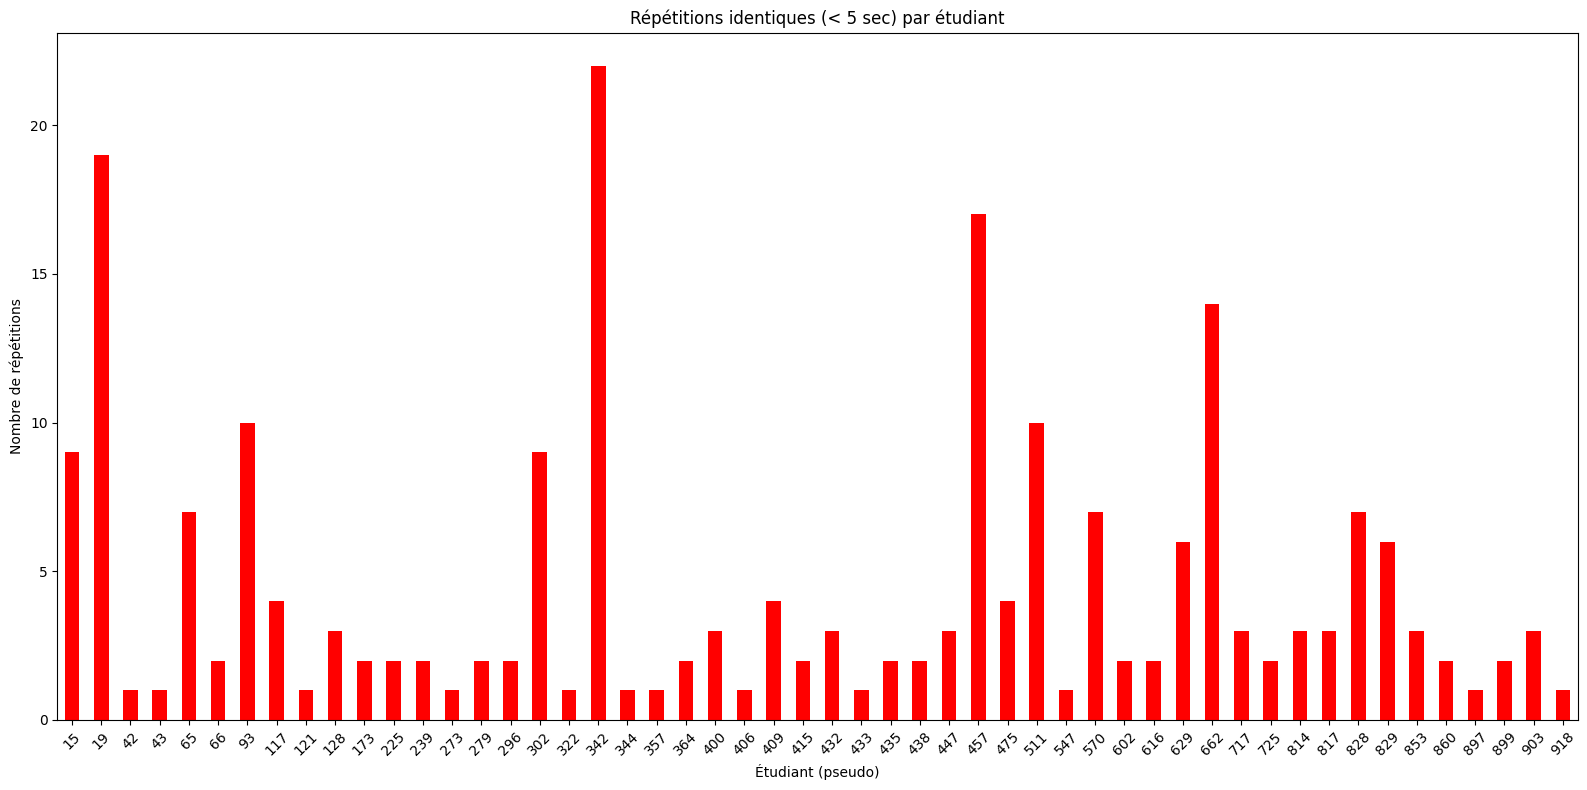

In [10]:
import matplotlib.pyplot as plt

# Compter les répétitions par pseudo
bugs_par_pseudo = log_clean[mask_bug].groupby('pseudo').size()

# Graphique
plt.figure(figsize=(16, 8))
bugs_par_pseudo.plot(kind='bar', color='red')
plt.title('Répétitions identiques (< 5 sec) par étudiant')
plt.xlabel('Étudiant (pseudo)')
plt.ylabel('Nombre de répétitions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
 #Supprimer ces lignes
log_clean = log_clean[~mask_bug]

# Vérifier
print(f"Après suppression des répétitions : {len(log_clean)} lignes")

Après suppression des répétitions : 15975 lignes


### Résumé du nettoyage
- Dataset original :  ***16227***
- Après doublons exacts :  ***16199***
- Après répétitions < 5 sec : ***15975***

## Analyse Exploratoire (EDA)

**Contexte**
Après le nettoyage des données (15 975 lignes), on analyse les logs selon 4 axes.

**Axe 1 : Temporel**
- Objectif : Identifier quand les étudiants travaillent (jours, heures, régularité)

**Axe 2 : Comportemental**
- Objectif : Comprendre les types d'actions réalisées sur la plateforme

**Axe 3 : Individuel**
- Objectif : Mesurer le niveau d'engagement de chaque étudiant

**Axe 4 : Ressources**
- Objectif : Identifier les ressources les plus consultées

### AXE 1 : Temporel

In [ ]:

log_clean['heure'] = pd.to_datetime(log_clean['heure'])

# Extraire les infos
log_clean['jour_semaine'] = log_clean['heure'].dt.day_name()
log_clean['heure_journee'] = log_clean['heure'].dt.hour
log_clean['semaine'] = log_clean['heure'].dt.isocalendar().week

In [13]:
print(log_clean['jour_semaine'].value_counts())

jour_semaine
Sunday       2799
Saturday     2702
Thursday     2556
Wednesday    2456
Friday       2140
Tuesday      1943
Monday       1379
Name: count, dtype: int64


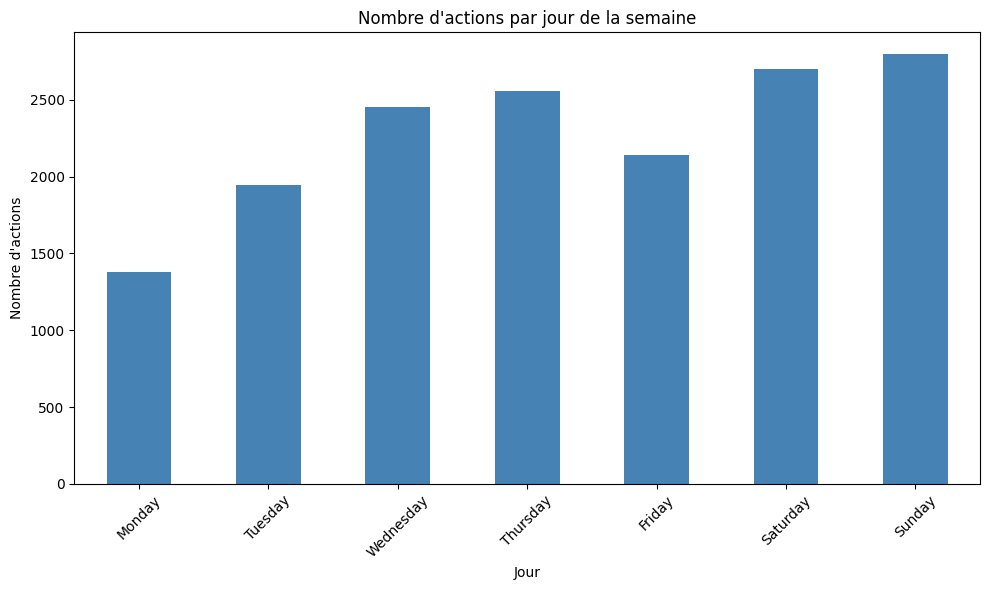

In [14]:
import matplotlib.pyplot as plt

# Compter les actions par jour
actions_par_jour = log_clean['jour_semaine'].value_counts()

# Ordonner les jours correctement
ordre_jours = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
actions_par_jour = actions_par_jour.reindex(ordre_jours)

# Graphique
plt.figure(figsize=(10, 6))
actions_par_jour.plot(kind='bar', color='steelblue')
plt.title('Nombre d\'actions par jour de la semaine')
plt.xlabel('Jour')
plt.ylabel('Nombre d\'actions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Interprétation - Actions par jour de la semaine
Les étudiants travaillent plus le weekend que la semaine !
Hypothèses possibles :

- Ils rattrapent le retard le weekend ?
- Moins de cours = plus de temps pour la plateforme ?
- Révisions avant les examens du lundi ?

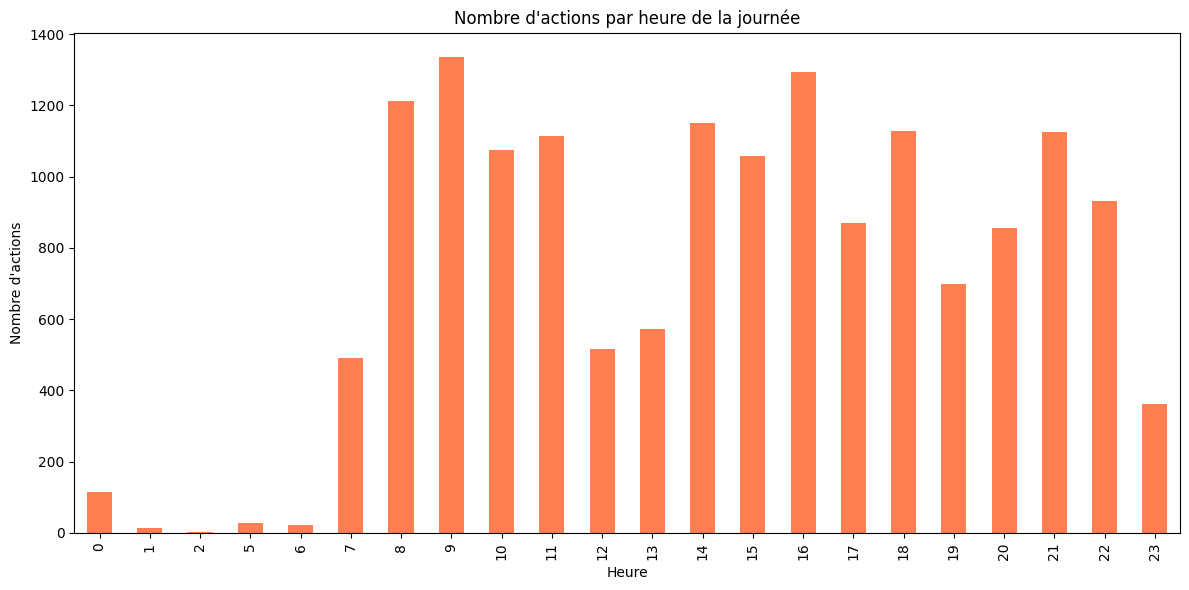

In [15]:
# Compter les actions par heure
actions_par_heure = log_clean['heure_journee'].value_counts().sort_index()

# Graphique
plt.figure(figsize=(12, 6))
actions_par_heure.plot(kind='bar', color='coral')
plt.title('Nombre d\'actions par heure de la journée')
plt.xlabel('Heure')
plt.ylabel('Nombre d\'actions')
plt.tight_layout()
plt.show()

#### Interprétation - Actions par heure de la journée
Les étudiants travaillent à trois moments :

- Matin (8h-11h) : Avant ou entre les cours
- Après-midi (14h-17h) : Entre les cours
- Soir (18h-22h) : Après les cours, chez eux

Creux à midi (12h-13h) → Pause déjeuner

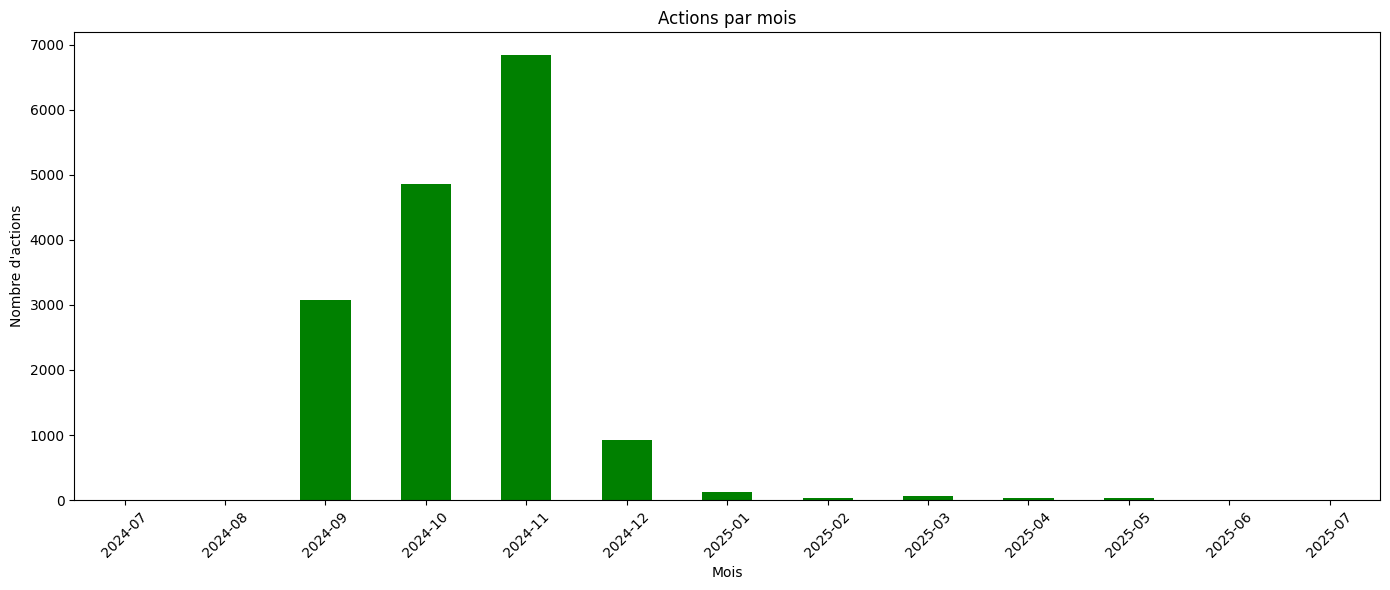

In [16]:
# Voir l'activité mois par mois (plus clair)
log_clean['mois'] = log_clean['heure'].dt.to_period('M')
actions_par_mois = log_clean['mois'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
actions_par_mois.plot(kind='bar', color='green')
plt.title('Actions par mois')
plt.xlabel('Mois')
plt.ylabel('Nombre d\'actions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

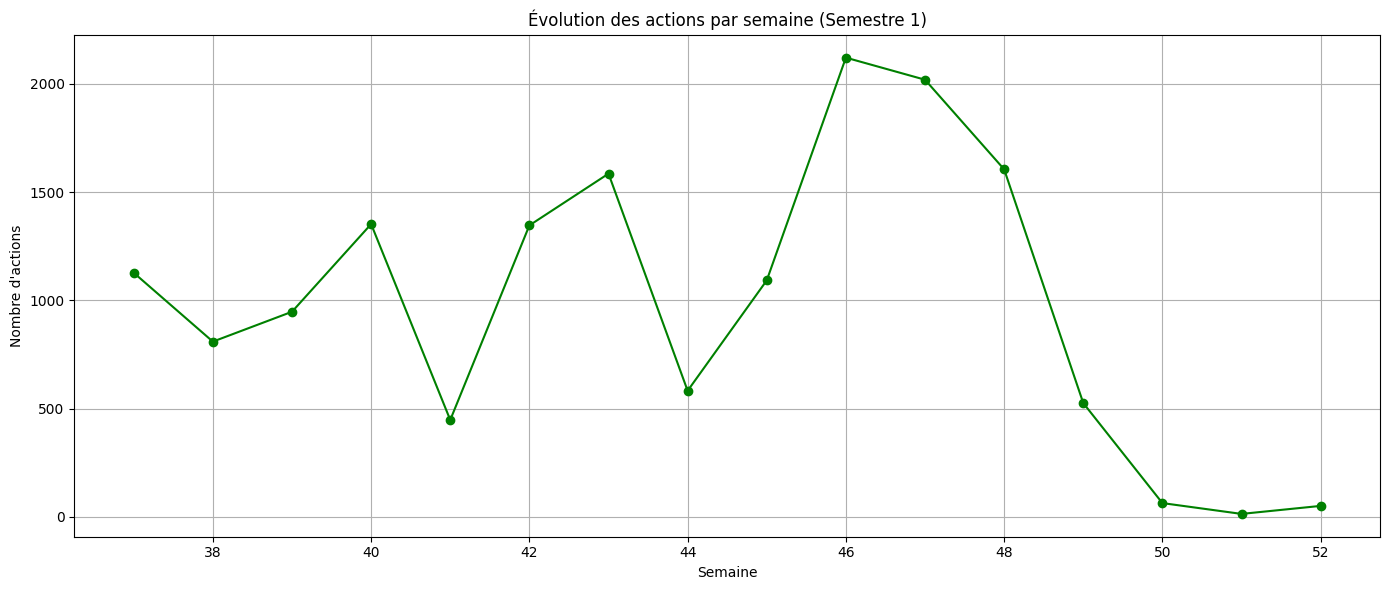

In [17]:
# Filtrer Semestre 1
log_s1 = log_clean[(log_clean['heure'] >= '2024-09-01') & (log_clean['heure'] <= '2024-12-31')]

# Graphique par semaine (seulement S1)
actions_par_semaine = log_s1['semaine'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
actions_par_semaine.plot(kind='line', marker='o', color='green')
plt.title('Évolution des actions par semaine (Semestre 1)')
plt.xlabel('Semaine')
plt.ylabel('Nombre d\'actions')
plt.grid(True)
plt.tight_layout()
plt.show()

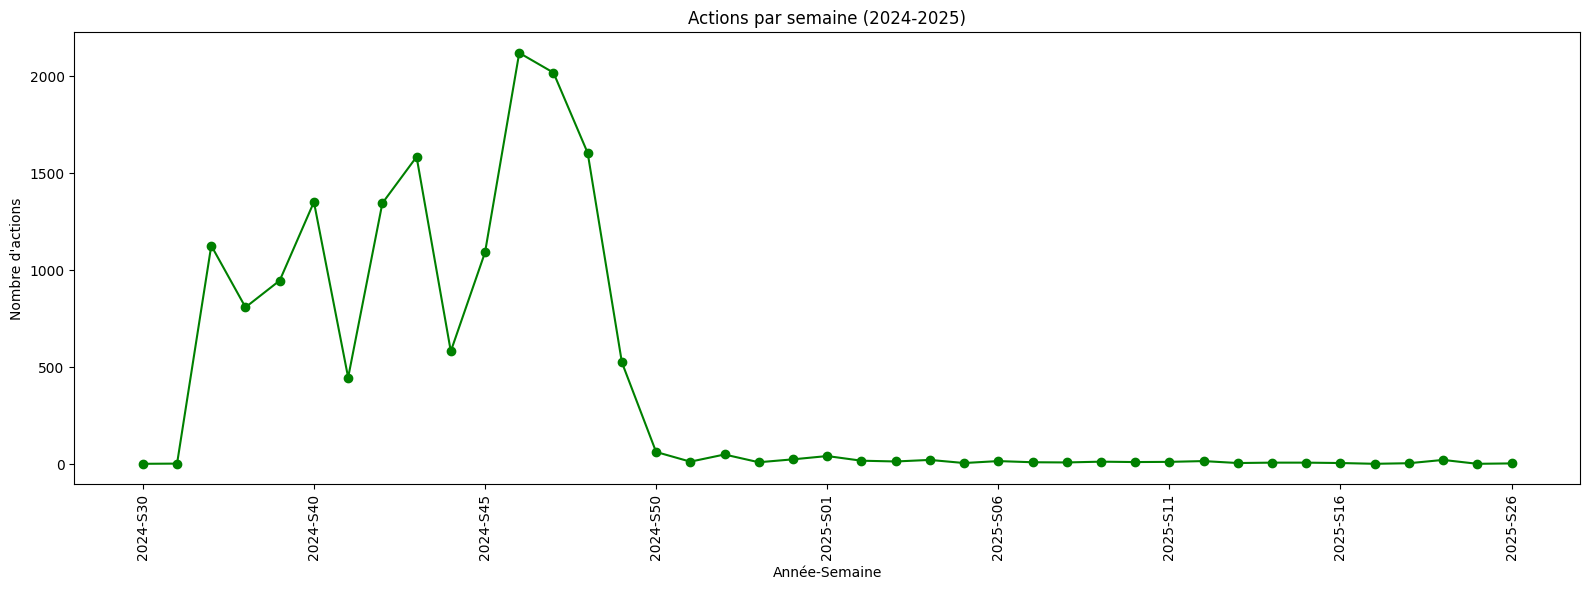

In [18]:
# Créer une colonne année-semaine
log_clean['annee_semaine'] = log_clean['heure'].dt.strftime('%Y-S%W')

# Compter
actions_par_semaine = log_clean['annee_semaine'].value_counts().sort_index()

# Graphique
plt.figure(figsize=(16, 6))
actions_par_semaine.plot(kind='line', marker='o', color='green')
plt.title('Actions par semaine (2024-2025)')
plt.xlabel('Année-Semaine')
plt.ylabel('Nombre d\'actions')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [19]:
log_2025 = log_clean[log_clean['heure'] >= '2025-01-01']
print(f"Actions en 2025 : {len(log_2025)}")
print("---------------- ") 
print(f"Étudiants en 2025 : {log_2025['pseudo'].nunique()}")
print("----------------")
log_2024 = log_clean[(log_clean['heure'] >= '2024-09-01') & (log_clean['heure'] <= '2024-12-31')]
print(f"Actions en S1 2024 : {len(log_2024)}")
print("----------------")
print(f"Étudiants en S1 2024 : {log_2024['pseudo'].nunique()}")

Actions en 2025 : 277
---------------- 
Étudiants en 2025 : 59
----------------
Actions en S1 2024 : 15683
----------------
Étudiants en S1 2024 : 104


#### Interprétation - Évolution par semaine
- 59 étudiants en 2025 : Certains étudiants reviennent
- Seulement 5 actions/étudiant : Ils consultent très peu

Hypothèse la plus probable
Ce cours est un cours du Semestre 1 uniquement.
Les 277 actions en 2025 sont probablement :
- Des étudiants qui reconsultent leurs anciens cours
- Des rattrapages
- Des accès résiduels

### AXE 2 : Comportemental

composant
Test                      9110
Système                   3774
Fichier                   2591
Forum                       81
Visites guidées             48
Rapport du participant      30
URL                         26
Feedback                    23
Name: count, dtype: int64
------------------------------


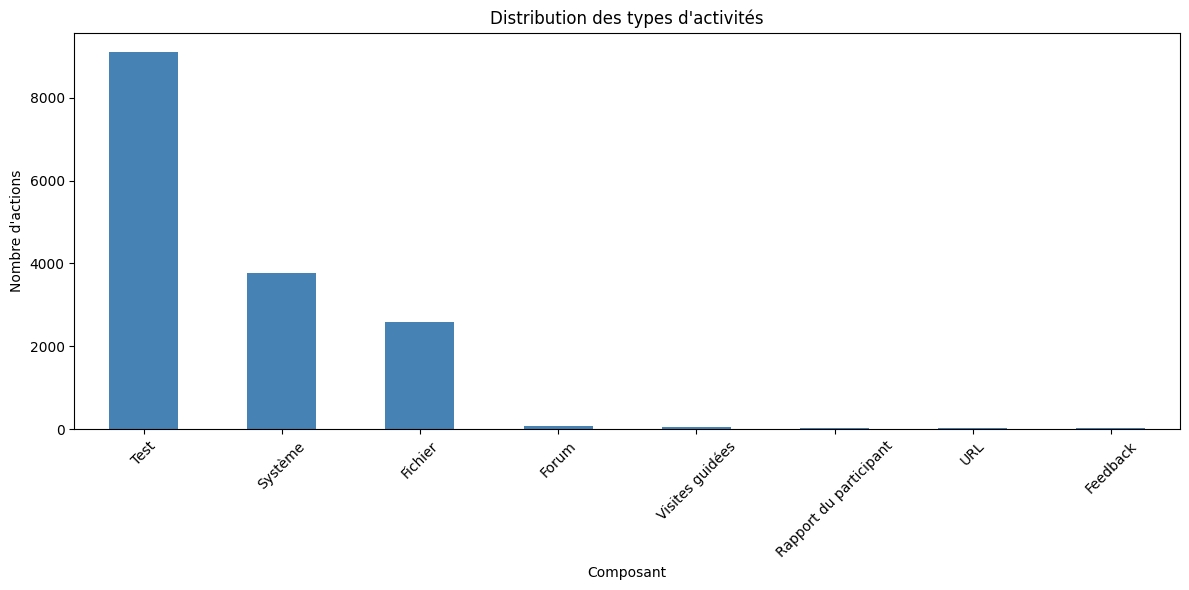

In [20]:
# Compter les composants
print(log_s1['composant'].value_counts())

print("------------------------------")

# Graphique
composants = log_s1['composant'].value_counts()

plt.figure(figsize=(12, 6))
composants.plot(kind='bar', color='steelblue')
plt.title('Distribution des types d\'activités')
plt.xlabel('Composant')
plt.ylabel('Nombre d\'actions')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# Voir les pseudos dans notes
print(f"Étudiants dans notes : {notes['pseudo'].nunique()}")

# Comparer avec log_s1
etudiants_s1 = set(log_s1['pseudo'].unique())
etudiants_notes = set(notes['pseudo'].unique())

print(f"Étudiants en commun : {len(etudiants_s1 & etudiants_notes)}")

Étudiants dans notes : 99
Étudiants en commun : 94


In [22]:
# les événements
print(log_clean['evenement'].value_counts())

evenement
Module de cours consulté                           4415
Cours consulté                                     2991
Tentative de test relue                            1321
Tentative de test consultée                        1303
Résumé de tentative de test consulté               1175
Tentative de test commencée                        1174
Tentative de test modifiée                         1171
Tentative de test envoyée                          1130
Utilisateur évalué                                  852
Tentative de test enregistrée automatiquement       207
Liste d’utilisateurs consultée                      100
Profil utilisateur consulté                          33
Rapport d’évaluation utilisateur consulté            32
Visite guidée terminée                               18
Visite guidée commencée                              18
Visite guidée relancée                               12
Discussion consultée                                  8
Rapport de cours utilisateur consulté 

evenement
Module de cours consulté                           4343
Cours consulté                                     2800
Tentative de test relue                            1319
Tentative de test consultée                        1302
Résumé de tentative de test consulté               1174
Tentative de test commencée                        1173
Tentative de test modifiée                         1170
Tentative de test envoyée                          1129
Utilisateur évalué                                  851
Tentative de test enregistrée automatiquement       206
Liste d’utilisateurs consultée                       94
Rapport d’évaluation utilisateur consulté            30
Profil utilisateur consulté                          27
Visite guidée commencée                              18
Visite guidée terminée                               18
Visite guidée relancée                               12
Discussion consultée                                  7
Réponse remise                        

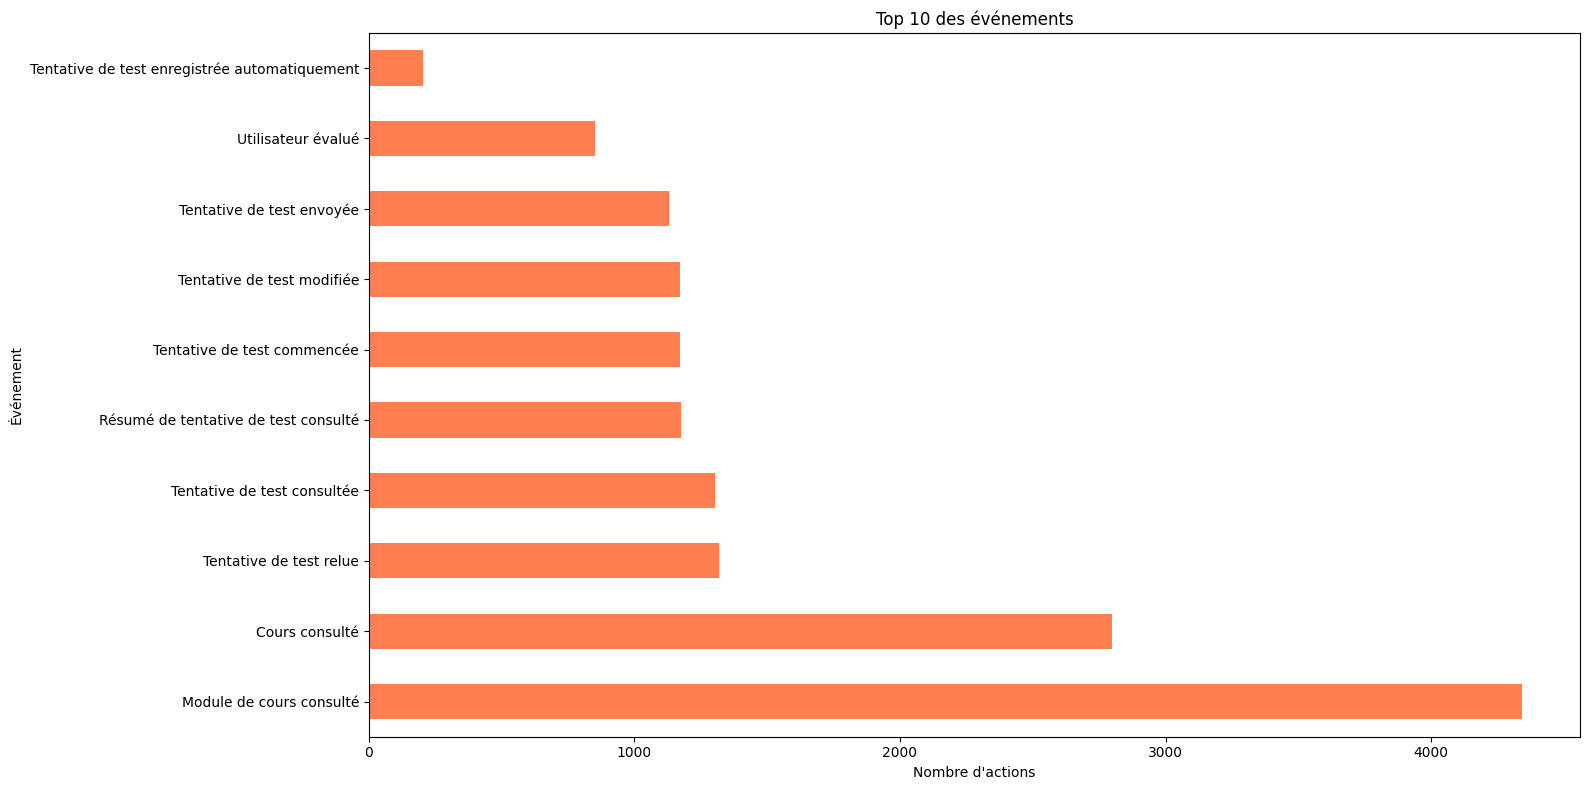

In [23]:
# Compter les événements
print(log_s1['evenement'].value_counts())

print("------------------------------")

# Top 10 des événements
evenements = log_s1['evenement'].value_counts().head(10)

plt.figure(figsize=(16, 8))
evenements.plot(kind='barh', color='coral')
plt.title('Top 10 des événements')
plt.xlabel('Nombre d\'actions')
plt.ylabel('Événement')
plt.tight_layout()
plt.show()

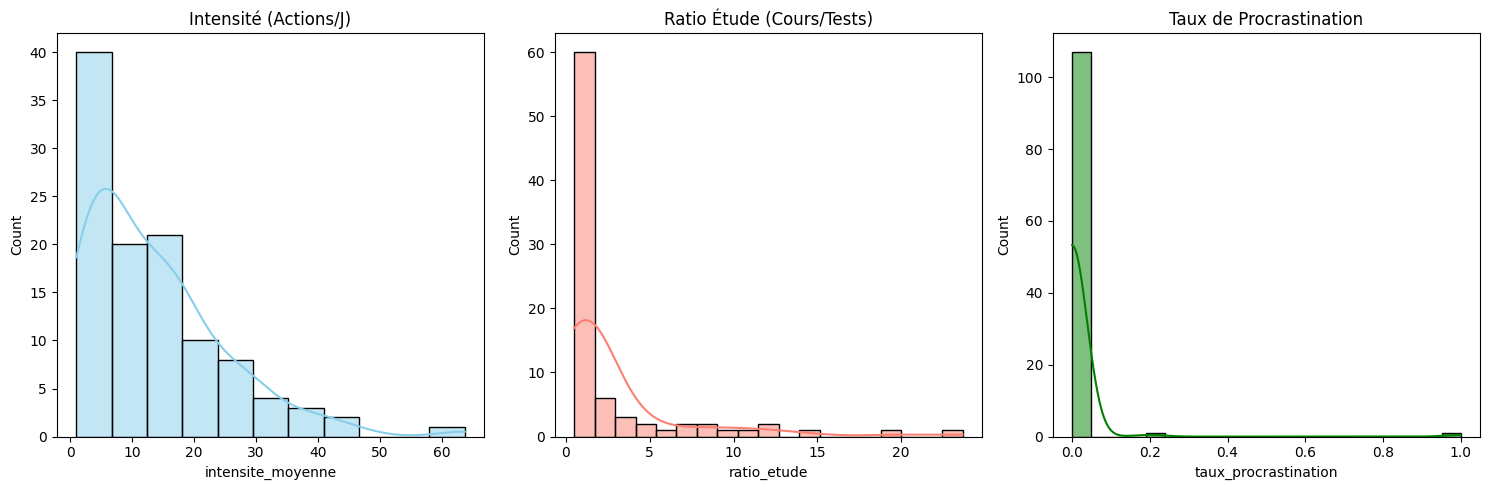

In [ ]:
import seaborn as sns

# 1. L'Intensité (Régularité) : Actions par jour de connexion réel
jours_actifs = log_clean.groupby('pseudo')['heure'].apply(lambda x: x.dt.date.nunique())
intensite = (log_clean.groupby('pseudo').size() / jours_actifs).reset_index(name='intensite_moyenne')

# 2. Le Ratio d'Étude (Théorie vs Pratique)
# On compare les consultations aux tests pour voir la stratégie
nb_tests = log_clean[log_clean['composant'] == 'Test'].groupby('pseudo').size()
nb_consults = log_clean[log_clean['evenement'].str.contains('consulté', case=False)].groupby('pseudo').size()
ratio_etude = (nb_consults / (nb_tests + 1)).reset_index(name='ratio_etude')

# 3. Le Taux de Procrastination (Dernière quinzaine du semestre)
date_limite = log_clean['heure'].max() - pd.Timedelta(days=15)
actions_fin = log_clean[log_clean['heure'] >= date_limite].groupby('pseudo').size()
procrastination = (actions_fin / log_clean.groupby('pseudo').size()).reset_index(name='taux_procrastination').fillna(0)

# Visualisation des nouveaux indicateurs
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1); sns.histplot(intensite['intensite_moyenne'], color='skyblue', kde=True); plt.title('Intensité (Actions/J)')
plt.subplot(1, 3, 2); sns.histplot(ratio_etude['ratio_etude'], color='salmon', kde=True); plt.title('Ratio Étude (Cours/Tests)')
plt.subplot(1, 3, 3); sns.histplot(procrastination['taux_procrastination'], color='green', kde=True); plt.title('Taux de Procrastination')
plt.tight_layout(); plt.show()

### Résumé Axe 2 : Comportemental (Version Enrichie)
**Objectif :** Décrypter non seulement le volume d'activité, mais surtout la **stratégie d'apprentissage** des étudiants.



**2.1 & 2.2 - Analyse des Volumes (Quantité) :**
* **Dominance des Tests :** Avec **58%** des actions totales portées sur le composant "Test" et un équilibre entre tests actifs (22%) et passifs (24%), la plateforme est avant tout utilisée comme un outil d'entraînement.
* **Accès aux Ressources :** La consultation représente **46%** des événements. Les étudiants passent donc autant de temps à "s'informer" qu'à "s'évaluer".

**2.3 - Analyse des Profils (Qualité & Stratégie) :**
L'introduction des variables comportementales basées sur `log_clean` apporte un éclairage crucial sur la **méthode** des étudiants :
* **Stratégie d'Étude (Ratio) :** Le volume de tests (58%) doit être mis en perspective avec le **Ratio d'Étude**. Nous observons des profils "Praticiens" (qui enchaînent les tests avec peu de lectures) versus des profils "Théoriciens". Une stratégie "essai-erreur" sans consultation préalable de fichiers est un facteur de risque identifié.
* **Régularité (Intensité) :** L'analyse de l'**Intensité** montre que le nombre d'actions n'est pas réparti uniformément. Une forte intensité (beaucoup d'actions sur peu de jours) indique un travail "massifié" souvent moins efficace pour la rétention que le travail régulier.
* **Gestion du Stress (Procrastination) :** Le **Taux de Procrastination** révèle si l'engagement massif observé est une démarche de fond ou une réaction d'urgence. Un taux élevé indique que l'essentiel du travail (notamment les tests) est réalisé dans les 15 derniers jours, ce qui impacte la qualité de l'apprentissage.

---

> **Conclusion de l'Axe 2 :** L'engagement sur Arche n'est pas une simple question de "nombre de clics". La réussite semble dépendre de l'**équilibre** entre théorie et pratique (Ratio) et de la **constance** de l'effort (Intensité). Ce sont ces trois indicateurs stratégiques qui serviront de base à notre **Feature Engineering** pour améliorer la précision de notre modèle de prédiction.


### AXE 3 : Individuel

In [25]:
# Actions par étudiant
actions_par_etudiant = log_s1.groupby('pseudo').size()

# Statistiques
print(actions_par_etudiant.describe())

count     104.000000
mean      150.798077
std       220.156978
min         1.000000
25%        19.750000
50%        82.500000
75%       211.750000
max      1782.000000
dtype: float64


In [26]:
# Actions par étudiant
actions_par_etudiant_1 = log_clean.groupby('pseudo').size()

# Statistiques
print(actions_par_etudiant_1.describe())

count     109.000000
mean      146.559633
std       217.494761
min         1.000000
25%        18.000000
50%        71.000000
75%       209.000000
max      1782.000000
dtype: float64


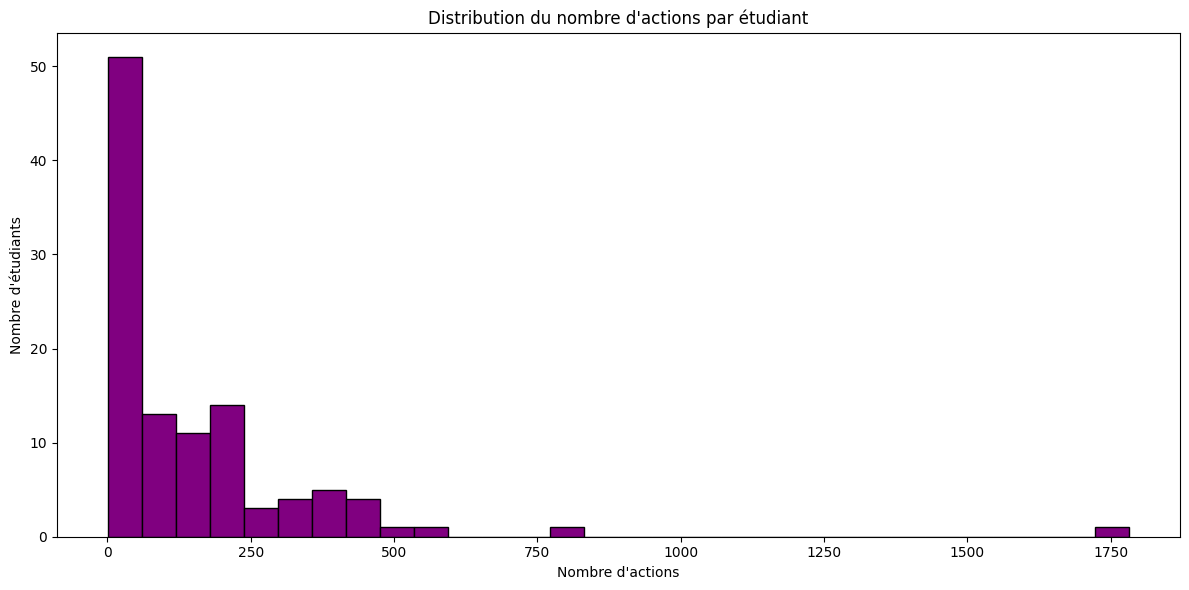

In [27]:
# Distribution des actions par étudiant
plt.figure(figsize=(12, 6))
actions_par_etudiant_1.plot(kind='hist', bins=30, color='purple', edgecolor='black')
plt.title('Distribution du nombre d\'actions par étudiant')
plt.xlabel('Nombre d\'actions')
plt.ylabel('Nombre d\'étudiants')
plt.tight_layout()
plt.show()

#### Interprétation
Groupe: Peu actifs 
- 0-50 (Actions)
- ~51 (étudiants)  
- Consultent rarement

Groupe : Moyennement actifs
- 50-250 (Actions)
- ~40 (étudiants)
- Engagement normal 

Groupe : Très actifs
- 250-500 (Actions)
- ~15 (étudiants) 
- Très engagés

Groupe : Extrêmes
- 750+ (Actions)
- ~2 (étudiants) 
-  Outliers

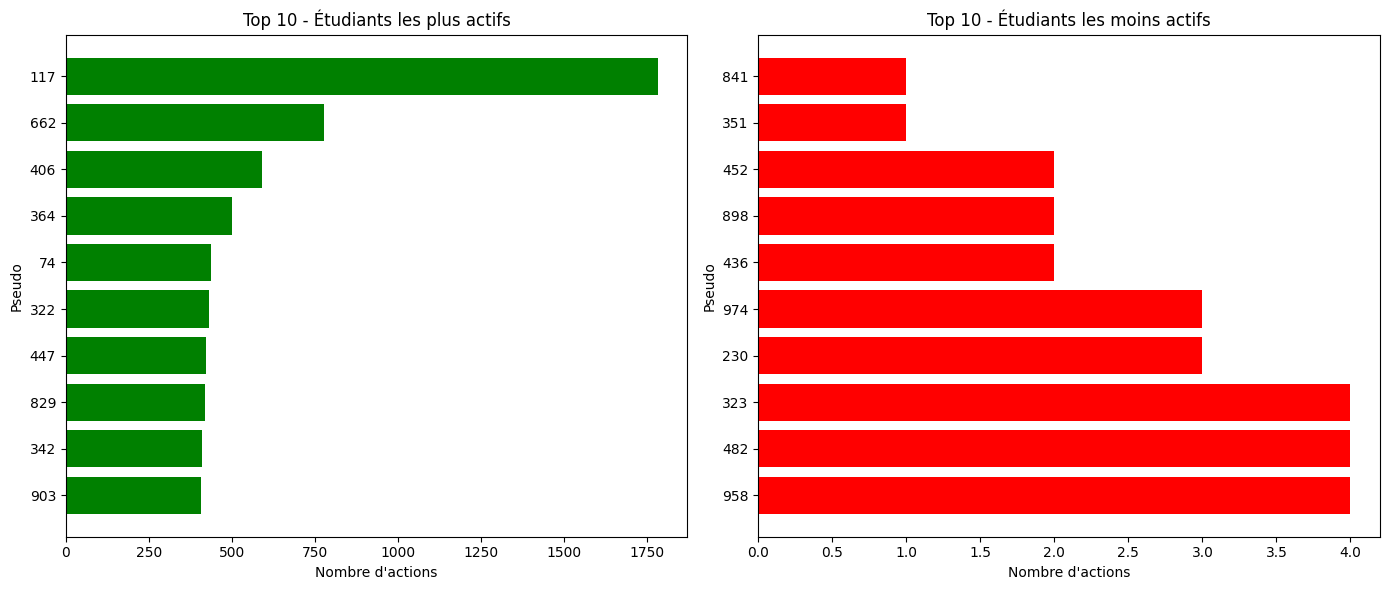

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Graphique 1 : Top 10 les plus actifs
top_10 = actions_par_etudiant_1.sort_values(ascending=False).head(10)
axes[0].barh(top_10.index.astype(str), top_10.values, color='green')
axes[0].set_xlabel('Nombre d\'actions')
axes[0].set_ylabel('Pseudo')
axes[0].set_title('Top 10 - Étudiants les plus actifs')
axes[0].invert_yaxis()

# Graphique 2 : Top 10 les moins actifs
bottom_10 = actions_par_etudiant_1.sort_values(ascending=True).head(10)
axes[1].barh(bottom_10.index.astype(str), bottom_10.values, color='red')
axes[1].set_xlabel('Nombre d\'actions')
axes[1].set_ylabel('Pseudo')
axes[1].set_title('Top 10 - Étudiants les moins actifs')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

    pseudo  nb_actions    note
38     351           1  10.611
52     452           2  10.312
92     974           3   8.811
25     230           3  10.628
3       38           4   8.249
60     540           4  11.313
71     632           6   9.008
53     454           8   9.627
41     392           8  10.584
24     227          10  10.005
______________________________________________________________


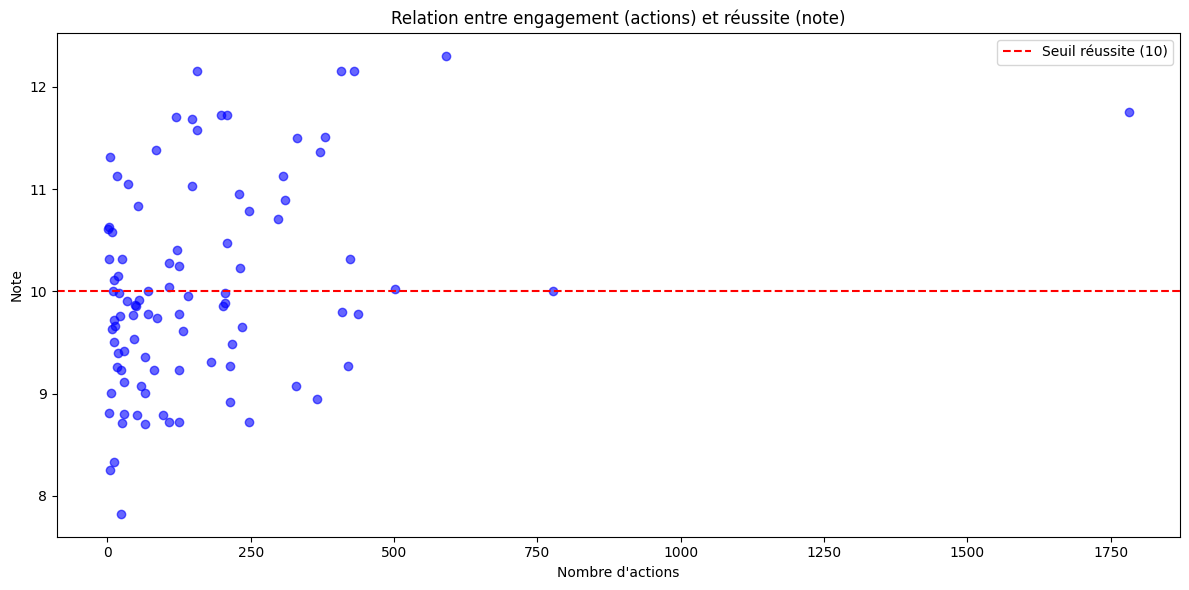

In [29]:
# Fusionner avec les notes
actions_avec_notes = actions_par_etudiant_1.reset_index()
actions_avec_notes.columns = ['pseudo', 'nb_actions']
actions_avec_notes = actions_avec_notes.merge(notes, on='pseudo', how='inner')

# Voir les moins actifs avec leur note
print(actions_avec_notes.sort_values('nb_actions').head(10))

print("______________________________________________________________")

# Fusionner avec les notes
actions_avec_notes = actions_par_etudiant_1.reset_index()
actions_avec_notes.columns = ['pseudo', 'nb_actions']
actions_avec_notes = actions_avec_notes.merge(notes, on='pseudo', how='inner')

# Graphique : Scatter plot
plt.figure(figsize=(12, 6))
plt.scatter(actions_avec_notes['nb_actions'], actions_avec_notes['note'], color='blue', alpha=0.6)
plt.xlabel('Nombre d\'actions')
plt.ylabel('Note')
plt.title('Relation entre engagement (actions) et réussite (note)')
plt.axhline(y=10, color='red', linestyle='--', label='Seuil réussite (10)')
plt.legend()
plt.tight_layout()
plt.show()


#### Interprétation
- Étudiant avec 1782 actions → note ~11.7 :  Très actif, bonne note
- Étudiants avec ~50 actions → notes de 8 à 12 :  Peu actifs, notes variées
- Étudiants avec ~200 actions → notes de 8.7 à 12.2 : Actifs, notes variées aussi

***Conclusion***

Plus d'actions ≠ meilleure note automatiquement

- Des étudiants peu actifs réussissent (note > 10)
- Des étudiants actifs échouent (note < 10)

L'engagement seul ne suffit pas → il faudra regarder le type d'actions (Axe 2), pas juste la quantité.


In [30]:
# Calculer la corrélation
correlation = actions_avec_notes['nb_actions'].corr(actions_avec_notes['note'])
print(f"Corrélation actions-note : {correlation:.3f}")

Corrélation actions-note : 0.355


### AXE 4 : Ressources
Objectif : Identifier les ressources les plus consultées

Nombre de ressources : 108
contexte
Cours: PASS - S1 - UE Disciplinaire Informatique : partie #1    2492
Cours: PASS - S1 - UE Disciplinaire Informatique : partie #2    1573
Test: Test : Ch. 1 – Variable, type et instructions de base      787
Test: Quiz Leçon 1                                               663
Test: Quiz Leçon 2                                               562
Test: Quiz – Leçon 1 : booléens                                  551
Test: Quiz – Leçon 1 : base                                      544
Test: Test : Ch. 2 – Conditionnelle simple                       511
Test: Quiz Leçon 3                                               510
Test: Quiz – Leçon 4                                             478
Test: Quiz – Leçon 1 : algorithmes                               477
Test: Quiz – Leçon 3                                             469
Test: Test : Ch. 3 – Les itérations                              448
Test: Test : Ch. 4 – Sous-algorithmes                            43

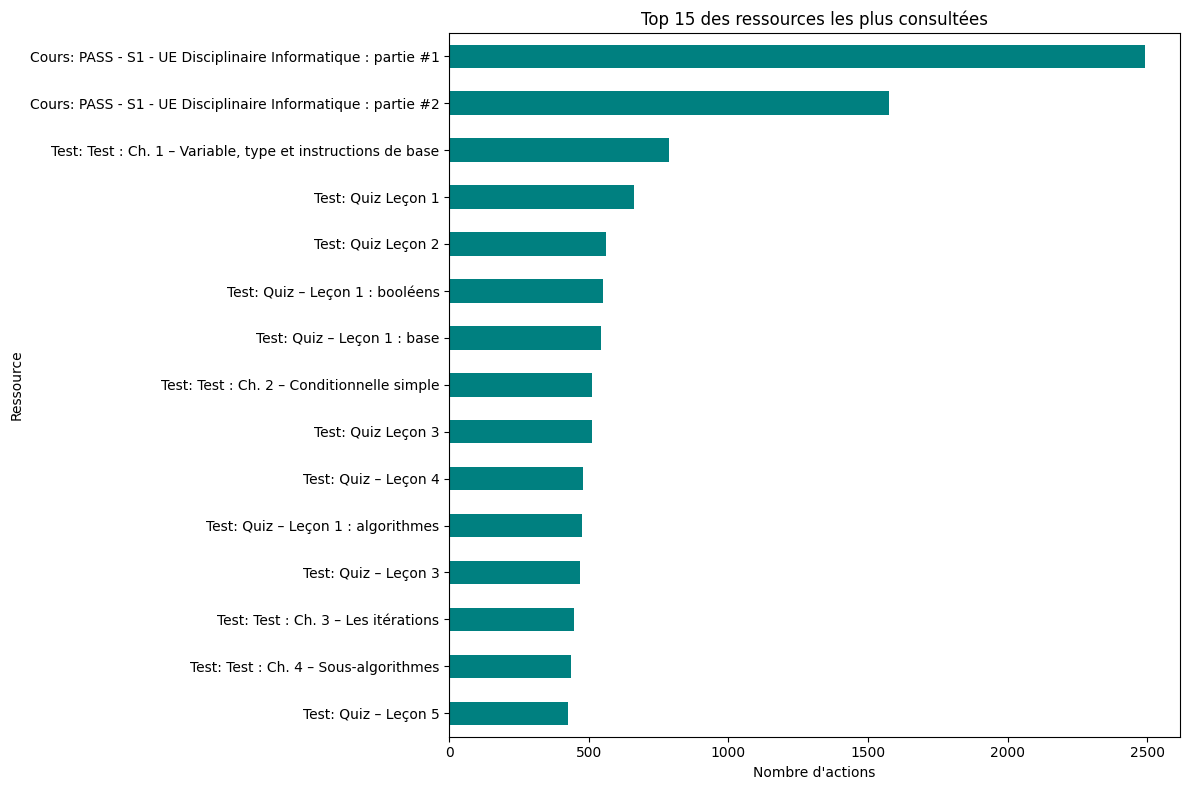

In [31]:
# Combien de ressources différentes ?
print(f"Nombre de ressources : {log_clean['contexte'].nunique()}")

# Top 15 des ressources les plus consultées
print(log_clean['contexte'].value_counts().head(15))

print("___________________________________________")
# Top 15 des ressources
top_ressources = log_clean['contexte'].value_counts().head(15)

plt.figure(figsize=(12, 8))
top_ressources.plot(kind='barh', color='teal')
plt.title('Top 15 des ressources les plus consultées')
plt.xlabel('Nombre d\'actions')
plt.ylabel('Ressource')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [32]:
# Extraire le type (avant les deux points)
log_clean['type_ressource'] = log_clean['contexte'].str.split(':').str[0]

# Compter par type
print(log_clean['type_ressource'].value_counts())

type_ressource
Test        9122
Cours       4065
Fichier     2565
Autre         88
Forum         83
Feedback      26
URL           26
Name: count, dtype: int64


In [33]:
# Nombre de ressources différentes consultées par étudiant
ressources_par_etudiant = log_clean.groupby('pseudo')['contexte'].nunique()

# Statistiques
print(ressources_par_etudiant.describe())

count    109.000000
mean      23.174312
std       20.629377
min        1.000000
25%        7.000000
50%       19.000000
75%       33.000000
max      105.000000
Name: contexte, dtype: float64


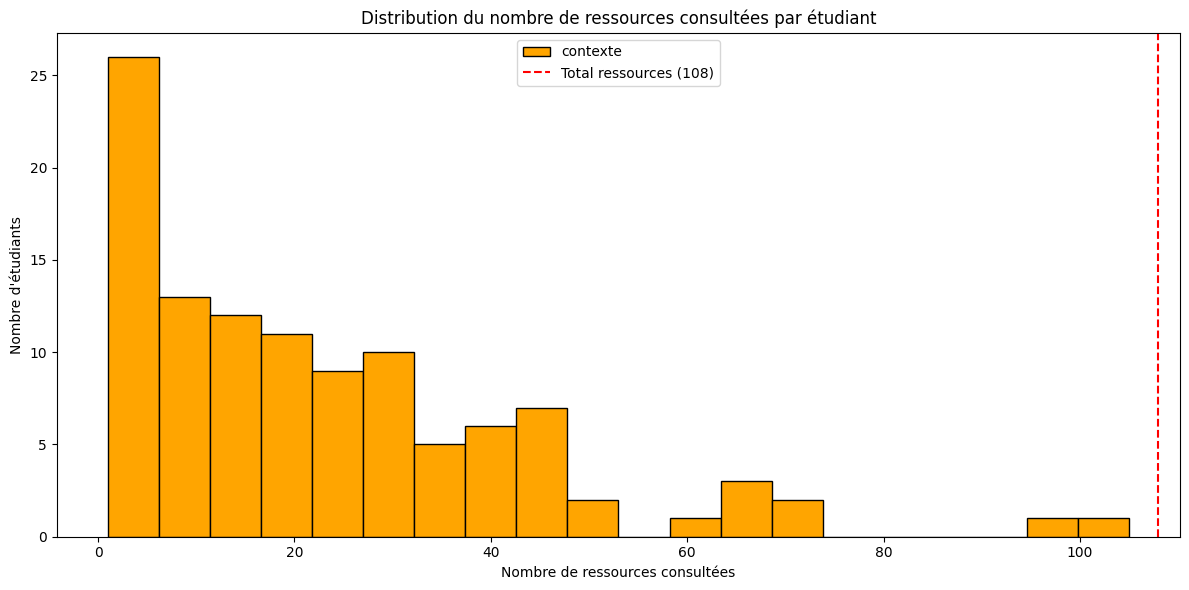

In [34]:
# Distribution de la couverture
plt.figure(figsize=(12, 6))
ressources_par_etudiant.plot(kind='hist', bins=20, color='orange', edgecolor='black')
plt.title('Distribution du nombre de ressources consultées par étudiant')
plt.xlabel('Nombre de ressources consultées')
plt.ylabel('Nombre d\'étudiants')
plt.axvline(x=108, color='red', linestyle='--', label='Total ressources (108)')
plt.legend()
plt.tight_layout()
plt.show()

In [35]:
# Fusionner couverture avec notes
couverture_avec_notes = ressources_par_etudiant.reset_index()
couverture_avec_notes.columns = ['pseudo', 'nb_ressources']
couverture_avec_notes = couverture_avec_notes.merge(notes, on='pseudo', how='inner')

# Corrélation
correlation = couverture_avec_notes['nb_ressources'].corr(couverture_avec_notes['note'])
print(f"Corrélation ressources-note : {correlation:.3f}")

Corrélation ressources-note : 0.440


#### Résumé
- 108 ressources : Disponibles sur la plateforme
- 57% = Tests : Les quiz dominent
- Moyenne consultation: 23 ressources/étudiant (21%)
- Corrélation ressources-note : 0.440 (modérée positive)

#### Conclusion 
- Consulter plus de ressources différentes = meilleure note

Un étudiant qui explore tout le cours réussit mieux qu'un étudiant qui répète les mêmes actions sur peu de ressources.

In [36]:
# Exporter le DataFrame nettoyé
log_clean.to_csv('df-log_clean.csv', index=False)

In [37]:
# Colonnes originales
colonnes_originales = ['heure', 'pseudo', 'contexte', 'composant', 'evenement']

# Sauvegarder
log_clean[colonnes_originales].to_csv('log_clean.csv', index=False)

## Feature Engineering 
- Objectif : Transformer les logs en une ligne par étudiant avec des features calculées.

In [38]:
df = pd.read_csv('df-log_clean.csv')

In [39]:
# Feature 1 : nb_actions
# Nombre total d'actions par étudiant
nb_actions = df.groupby('pseudo').size().reset_index(name='nb_actions')
print(nb_actions.head(10))
print(" --- Fin --- ")

# Feature 2 : nb_ressources
# Nombre de ressources différentes consultées par étudiant
nb_ressources = df.groupby('pseudo')['contexte'].nunique().reset_index(name='nb_ressources')
print(nb_ressources.head(10))
print(" --- Fin --- ")

# Feature 3 : nb_tests
# Nombre d'actions sur les Tests
nb_tests = df[df['composant'] == 'Test'].groupby('pseudo').size().reset_index(name='nb_tests')
print(nb_tests.head(10))
print(" --- Fin --- ")

# Feature 4 : nb_consultations
# Nombre de consultations (événements contenant "consulté")
nb_consultations = df[df['evenement'].str.contains('consulté', case=False)].groupby('pseudo').size().reset_index(name='nb_consultations')
print(nb_consultations.head(10))
print(" --- Fin --- ")

# Feature 5 : actions_weekend
# Nombre d'actions le weekend (samedi, dimanche)
actions_weekend = df[df['jour_semaine'].isin(['Saturday', 'Sunday'])].groupby('pseudo').size().reset_index(name='actions_weekend')
print(actions_weekend.head(10))
print(" --- Fin --- ")

# Feature 6 : actions_soir
# Nombre d'actions le soir (18h-22h)
actions_soir = df[(df['heure_journee'] >= 18) & (df['heure_journee'] <= 22)].groupby('pseudo').size().reset_index(name='actions_soir')
print(actions_soir.head(10))
print(" --- Fin --- ")

# Feature 7 : nb_jours_actifs
# Nombre de jours différents avec activité
df['date'] = pd.to_datetime(df['heure']).dt.date
nb_jours_actifs = df.groupby('pseudo')['date'].nunique().reset_index(name='nb_jours_actifs')
print(nb_jours_actifs.head(10))
print(" --- Fin --- ")


   pseudo  nb_actions
0      15         107
1      19         329
2      29          55
3      38           4
4      42         370
5      43          20
6      48          17
7      53          19
8      58          24
9      65         306
 --- Fin --- 
   pseudo  nb_ressources
0      15             23
1      19             48
2      29             24
3      38              3
4      42             72
5      43             11
6      48              4
7      53             10
8      58             21
9      65             41
 --- Fin --- 
   pseudo  nb_tests
0      15        49
1      19       187
2      29        10
3      42       191
4      43         1
5      48         8
6      53        11
7      58         3
8      65       199
9      66        34
 --- Fin --- 
   pseudo  nb_consultations
0      15                70
1      19               203
2      29                50
3      38                 4
4      42               249
5      43                20
6      48                

In [40]:
features = nb_actions.copy()

# Ajouter chaque feature
features = features.merge(nb_ressources, on='pseudo', how='left')
features = features.merge(nb_tests, on='pseudo', how='left')
features = features.merge(nb_consultations, on='pseudo', how='left')
features = features.merge(actions_weekend, on='pseudo', how='left')
features = features.merge(actions_soir, on='pseudo', how='left')
features = features.merge(nb_jours_actifs, on='pseudo', how='left')

features = features.merge(intensite, on='pseudo', how='left')
features = features.merge(ratio_etude, on='pseudo', how='left')
features = features.merge(procrastination, on='pseudo', how='left')

# Remplacer les NaN par 0 (étudiants sans certaines actions)
features = features.fillna(0)

# Ajouter les notes
features = features.merge(notes, on='pseudo', how='left')

# Créer la cible : réussite (1 si note >= 10, sinon 0)
features['reussite'] = (features['note'] >= 10).astype(int)

# Afficher le résultat
print(features.head(10))
print(" --- Fin --- ")
print(f"Shape : {features.shape}")
print(f"Colonnes : {features.columns.tolist()}")

   pseudo  nb_actions  nb_ressources  nb_tests  nb_consultations  \
0      15         107             23      49.0                70   
1      19         329             48     187.0               203   
2      29          55             24      10.0                50   
3      38           4              3       0.0                 4   
4      42         370             72     191.0               249   
5      43          20             11       1.0                20   
6      48          17              4       8.0                12   
7      53          19             10      11.0                14   
8      58          24             21       3.0                23   
9      65         306             41     199.0               174   

   actions_weekend  actions_soir  nb_jours_actifs  intensite_moyenne  \
0              1.0           2.0               16           6.687500   
1            204.0         197.0               10          32.900000   
2              2.0          11.0   

In [41]:
print(features['note'].isna().sum())

14


In [42]:
# supprime les étudiants sans note
features_clean = features.dropna(subset=['note'])

print(f"Avant : {len(features)} étudiants")
print(f"Après : {len(features_clean)} étudiants")

Avant : 109 étudiants
Après : 95 étudiants


### **Conclusion**

La Phase 2 a permis de créer un dataset prêt pour la modélisation avec :

- 7 features décrivant le comportement de chaque étudiant
- 2 variables cibles (note et réussite)
- 95 observations exploitables

Les features capturent différents aspects du comportement :

- **Engagement** : `nb_actions`, `nb_jours_actifs`
- **Diversité** : `nb_ressources`
- **Type d'activité** : `nb_tests`, `nb_consultations`
- **Temporalité** : `actions_weekend`, `actions_soir`

In [43]:
# Sauvegarder les features
features_clean.to_csv('features.csv', index=False)
print("Features sauvegardées !")

Features sauvegardées !


In [4]:
import pandas as pd
DF = pd.read_csv('features.csv', index_col=0)
DF.head()

,nb_actions,nb_ressources,nb_tests,nb_consultations,actions_weekend,actions_soir,nb_jours_actifs,intensite_moyenne,ratio_etude,taux_procrastination,note,reussite
pseudo,,,,,,,,,,,,
15,107,23,49.0,70,1.0,2.0,16,6.687500,1.400000,0.0,8.718,0
19,329,48,187.0,203,204.0,197.0,10,32.900000,1.079787,0.0,9.070,0
29,55,24,10.0,50,2.0,11.0,10,5.500000,4.545455,0.0,9.917,0
38,4,3,0.0,4,0.0,0.0,1,4.000000,0.000000,0.0,8.249,0
42,370,72,191.0,249,197.0,0.0,12,30.833333,1.296875,0.0,11.366,1


Corrélation des variables avec la 'note' :
note                    1.000000
reussite                0.805007
nb_ressources           0.439687
nb_consultations        0.360601
nb_actions              0.354787
intensite_moyenne       0.335541
actions_weekend         0.334390
nb_tests                0.308185
actions_soir            0.242061
nb_jours_actifs         0.212510
taux_procrastination   -0.002705
ratio_etude            -0.149825
Name: note, dtype: float64


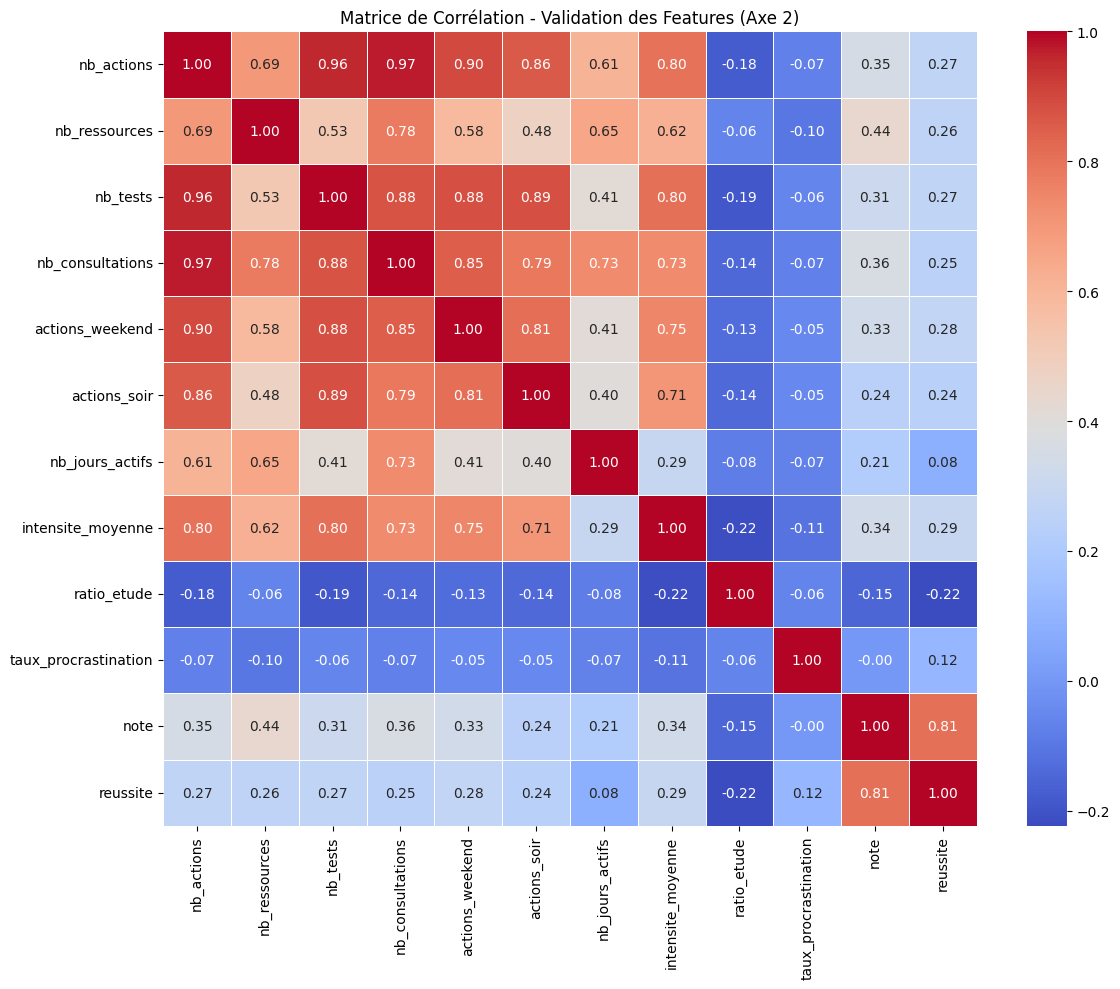

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load the file provided by the user
df = pd.read_csv('features.csv')

# Calculate the correlation matrix
# We exclude 'pseudo' as it's just an ID
corr_matrix = df.drop(columns=['pseudo']).corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice de Corrélation - Validation des Features (Axe 2)')
plt.tight_layout()
plt.savefig('heatmap_correlation_features.png')

# Display correlation with 'note' specifically
print("Corrélation des variables avec la 'note' :")
print(corr_matrix['note'].sort_values(ascending=False))

#### Interprétation Générale de la Matrice de Corrélation

L'analyse de la heatmap permet de hiérarchiser les facteurs qui influencent réellement la réussite des étudiants :

* **Les moteurs principaux (Volume et Diversité) :** La corrélation la plus élevée concerne la **diversité des ressources consultées**. Cela montre que la curiosité et l'exploration de contenus variés sont les meilleurs prédicteurs d'une bonne note. Le volume global d'activité confirme également qu'un engagement soutenu est synonyme de succès.

* **Le rythme et l'efficacité (Intensité) :** L'**intensité du travail** (le nombre d'actions réalisées par jour de connexion) apparaît comme un facteur clé, dépassant même la simple régularité sur la durée. Un étudiant qui travaille de manière dense et efficace, notamment durant le **week-end**, présente statistiquement de meilleurs résultats.

* **La stratégie d'apprentissage (Méthode) :** Les données révèlent qu'une stratégie trop axée sur la théorie pure (lecture seule) au détriment de la pratique (tests) peut être moins payante. L'équilibre penchant vers l'entraînement actif semble favoriser une meilleure assimilation des connaissances.

* **L'impact du timing :** Le moment de l'effort (travail précoce ou tardif) ne montre pas de lien linéaire direct avec la performance finale. La réussite dépend donc davantage de la **qualité** et de la **quantité** de l'effort fourni que du calendrier exact des révisions.

> **En résumé :** La réussite repose sur un trépied : **Curiosité** (variété des supports), **Engagement** (volume d'actions) et **Efficacité** (intensité de l'effort).